# Assignment 1 – Auditing and Explaining Diabetes Risk Prediction Models

**Client:** DiabetesPatientsRuleForever. **Data:** CDC BRFSS 2015, 50/50 balanced (`diabetes_binary_5050split_health_indicators_BRFSS2015.csv`).

Structure of this notebook (maps to the report):
1. Setup
2. Data import and codebook
3. Train / validation / test split
4. Candidate models and evaluation *(Report §1 Methodology)*
5. Global explanations: permutation importance, SHAP, LR coefficients *(§2)*
6. Local explanations: SHAP vs LIME for a single person
7. Validating the explanations: agreement, faithfulness, stability, **advice safety**
8. Error analysis and bias audit *(§4)*
9. Actionability: what-if and counterfactuals for the patient
10. Stakeholder figures: data scientist / director / patient *(§3–4)*

Reusable code lives in `xai_framework.py`. Figures are saved to `figures/<stakeholder>/`.

## 1. Setup

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import warnings
warnings.filterwarnings("ignore")

import xai_framework as xf
from xai_framework import FEATURES, TARGET, CODEBOOK, ACTIONABLE, MEDICAL, SENSITIVE, COLORS, MODEL_COLORS

xf.set_style()
pd.set_option("display.precision", 3)
np.random.seed(xf.SEED)

## 2. Data import and codebook

In [2]:
df = xf.load_data()
print(df.shape)
df.head()

(70692, 22)


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0,1,0,1,26,0,0,0,1,0,...,1,0,3,5,30,0,1,4,6,8
1,0,1,1,1,26,1,1,0,0,1,...,1,0,3,0,0,0,1,12,6,8
2,0,0,0,1,26,0,0,0,1,1,...,1,0,1,0,10,0,1,13,6,8
3,0,1,1,1,28,1,0,0,1,1,...,1,0,3,0,3,0,1,11,6,8
4,0,0,0,1,29,1,0,0,1,1,...,1,0,2,0,0,0,0,8,5,8


In [3]:
# Codebook: plain-language labels + how actionable each feature is + whether it is sensitive
codebook = pd.DataFrame({f: vars(v) for f, v in CODEBOOK.items()}).T.drop(columns="values")
codebook

,label,description,kind,actionable,sensitive
HighBP,High blood pressure,Ever told by a health professional you have hi...,binary,medical,False
HighChol,High cholesterol,Ever told your blood cholesterol is high,binary,medical,False
CholCheck,Cholesterol check (5 yrs),Cholesterol checked within past 5 years,binary,no,False
BMI,Body mass index (BMI),Body mass index,continuous,yes,False
Smoker,Has smoked (100+ cigarettes),Smoked at least 100 cigarettes in entire life,binary,no,False
Stroke,Has had a stroke,Ever told you had a stroke,binary,no,False
HeartDiseaseorAttack,Heart disease / heart attack,Coronary heart disease or myocardial infarction,binary,no,False
PhysActivity,Physically active,Physical activity in past 30 days (not job),binary,yes,False
Fruits,Eats fruit daily,Consume fruit 1+ times per day,binary,yes,False
Veggies,Eats vegetables daily,Consume vegetables 1+ times per day,binary,yes,False


In [4]:
print("Class balance:", df[TARGET].value_counts().to_dict())
print("Missing values:", int(df.isna().sum().sum()))
print("Exact duplicate rows:", int(df.duplicated().sum()), "(plausible: many features are binary/ordinal)")
df.describe().T[["mean", "std", "min", "max"]]

Class balance: {0: 35346, 1: 35346}
Missing values: 0
Exact duplicate rows: 1635 (plausible: many features are binary/ordinal)


,mean,std,min,max
Diabetes_binary,0.500,0.500,0.0,1.0
HighBP,0.563,0.496,0.0,1.0
HighChol,0.526,0.499,0.0,1.0
CholCheck,0.975,0.155,0.0,1.0
BMI,29.857,7.114,12.0,98.0
Smoker,0.475,0.499,0.0,1.0
Stroke,0.062,0.241,0.0,1.0
HeartDiseaseorAttack,0.148,0.355,0.0,1.0
PhysActivity,0.703,0.457,0.0,1.0
Fruits,0.612,0.487,0.0,1.0


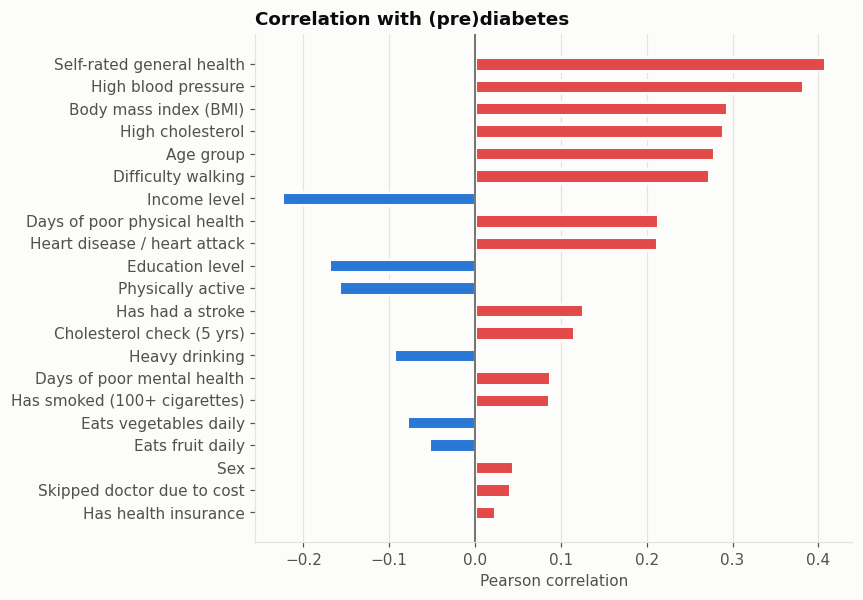

In [5]:
# First sanity check: raw association of each feature with the target.
# Watch for counter-intuitive signs (e.g. heavy drinking) - these can leak into
# explanations and become unsafe advice.
assoc = df.corr()[TARGET].drop(TARGET).sort_values()
fig, ax = plt.subplots(figsize=(7, 6))
xf.plot_contributions(ax, assoc / 100, title="Correlation with (pre)diabetes", xlabel="Pearson correlation", max_features=21)
plt.show()

## 3. Train / validation / test split

In [6]:
X_train, X_val, X_test, y_train, y_val, y_test = xf.split_data(df)
print({k: len(v) for k, v in dict(train=X_train, val=X_val, test=X_test).items()})

{'train': 49483, 'val': 7070, 'test': 14139}


## 4. Candidate models *(Report §1)*

| Model | Why |
|---|---|
| Logistic regression | Transparent baseline, additive in log-odds, coefficients are a global explanation |
| Random forest | Non-linear, captures interactions, robust; bagging |
| Gradient boosting (HistGB) | Usually strongest on tabular data; boosting |
| Neural network (MLP 64-32, ReLU) | Flexible non-linear black box; only post-hoc explainable (SHAP/LIME via permutation) |

`TODO:` hyper-parameter tuning on the validation set (e.g. `GridSearchCV` / a small manual sweep) – document it in the report.

In [7]:
models = xf.make_models()
for name, m in models.items():
    m.fit(X_train, y_train)

results = pd.DataFrame({name: xf.evaluate(m, X_val, y_val) for name, m in models.items()}).T
results

,AUC,Accuracy,Recall (sensitivity),Specificity,Precision,F1,Brier
Logistic regression,0.828,0.751,0.771,0.730,0.741,0.756,0.168
Random forest,0.831,0.749,0.789,0.709,0.730,0.759,0.167
Gradient boosting,0.834,0.753,0.795,0.711,0.733,0.763,0.165
Neural network,0.832,0.755,0.787,0.724,0.740,0.763,0.166


In [8]:
# Choose the model to explain in depth (update after looking at the table above)
MAIN = "Gradient boosting"
main = models[MAIN]
print("Test performance of", MAIN)
pd.Series(xf.evaluate(main, X_test, y_test))

Test performance of Gradient boosting


AUC                     0.830
Accuracy                0.750
Recall (sensitivity)    0.796
Specificity             0.704
Precision               0.729
F1                      0.761
Brier                   0.167
dtype: float64

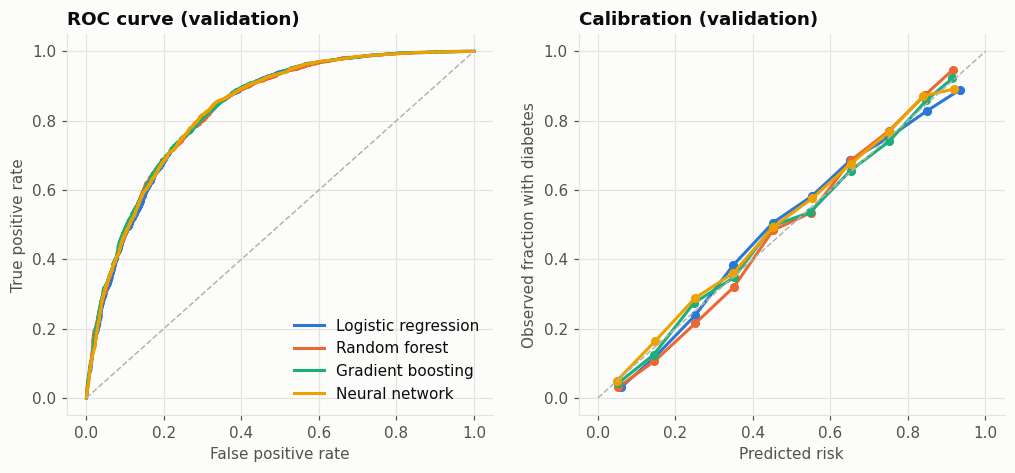

In [9]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import roc_curve

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for name, m in models.items():
    p = m.predict_proba(X_val)[:, 1]
    fpr, tpr, _ = roc_curve(y_val, p)
    axes[0].plot(fpr, tpr, lw=2, color=MODEL_COLORS[name], label=name)
    frac, mean_p = calibration_curve(y_val, p, n_bins=10)
    axes[1].plot(mean_p, frac, lw=2, marker="o", ms=5, color=MODEL_COLORS[name], label=name)
for ax in axes:
    ax.plot([0, 1], [0, 1], ls="--", color=COLORS["neutral"], lw=1)
axes[0].set(title="ROC curve (validation)", xlabel="False positive rate", ylabel="True positive rate")
axes[1].set(title="Calibration (validation)", xlabel="Predicted risk", ylabel="Observed fraction with diabetes")
axes[0].legend(loc="lower right")
plt.show()

## 5. Global explanations *(Report §2)*

Two XAI methods (plus LR coefficients as a sanity reference):
- **Permutation feature importance** – model-agnostic, global, measured on performance (AUC drop).
- **SHAP** – additive local attributions in probability units; averaged |SHAP| gives a global view and signs give direction.

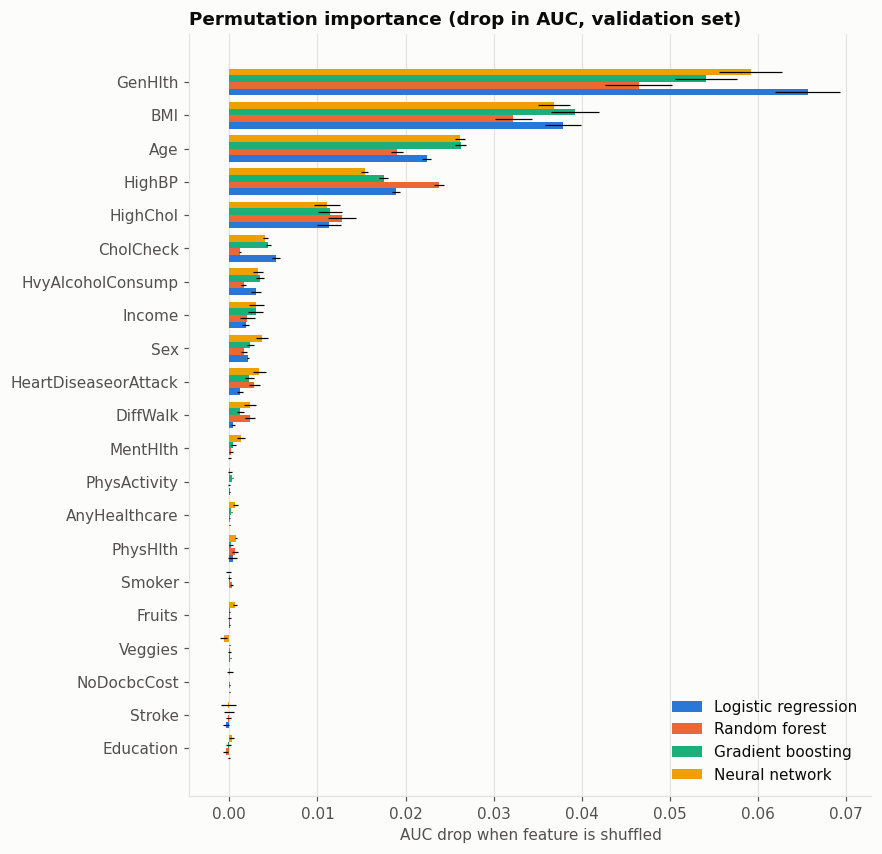

In [10]:
perm = {name: xf.perm_importance(m, X_val, y_val, n_repeats=5) for name, m in models.items()}

fig, ax = plt.subplots(figsize=(8, 9))
order = perm[MAIN]["mean"].sort_values().index
h = 0.8 / len(perm)
for i, (name, pi) in enumerate(perm.items()):
    ax.barh(np.arange(len(order)) + (i - (len(perm) - 1) / 2) * h, pi.loc[order, "mean"], height=h,
            xerr=pi.loc[order, "std"], color=MODEL_COLORS[name], label=name, error_kw=dict(lw=0.8))
ax.set_yticks(np.arange(len(order)), order)
ax.set(title="Permutation importance (drop in AUC, validation set)", xlabel="AUC drop when feature is shuffled")
ax.grid(axis="y", visible=False); ax.legend()
plt.show()

In [11]:
# SHAP for all models on the same sample of test persons (probability units)
X_explain = X_test.sample(1000, random_state=xf.SEED)
shap_expl = {name: xf.ShapExplainer(m, X_train) for name, m in models.items()}
shap_vals = {name: e(X_explain) for name, e in shap_expl.items()}   # LR + NN (permutation explainer) take ~1-2 min each

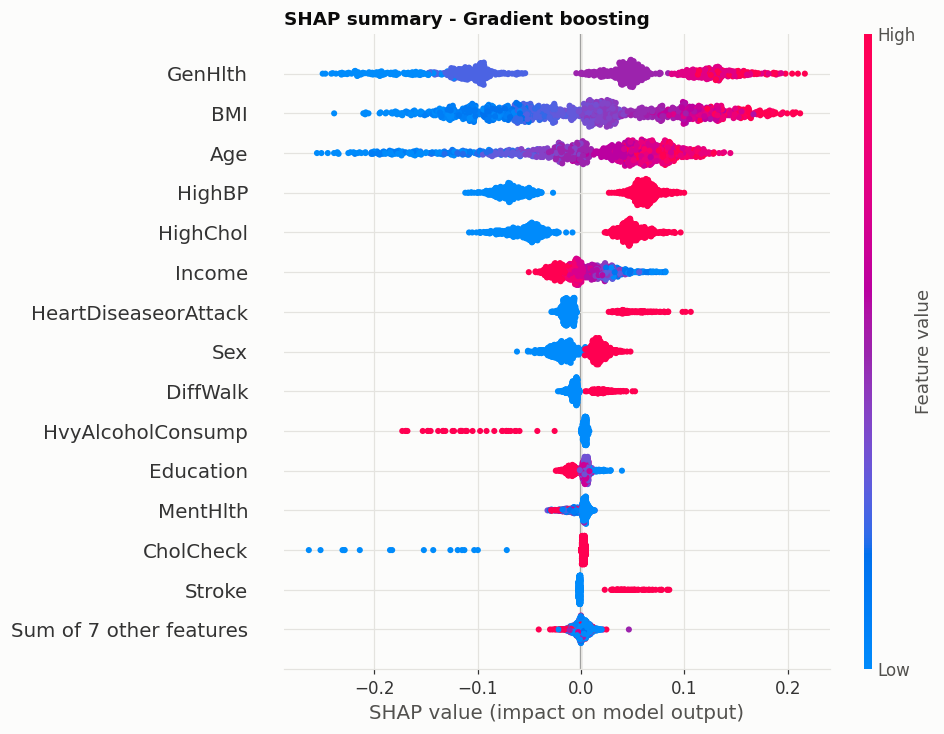

In [12]:
shap.plots.beeswarm(shap_vals[MAIN], max_display=15, show=False)
plt.title(f"SHAP summary - {MAIN}"); plt.show()

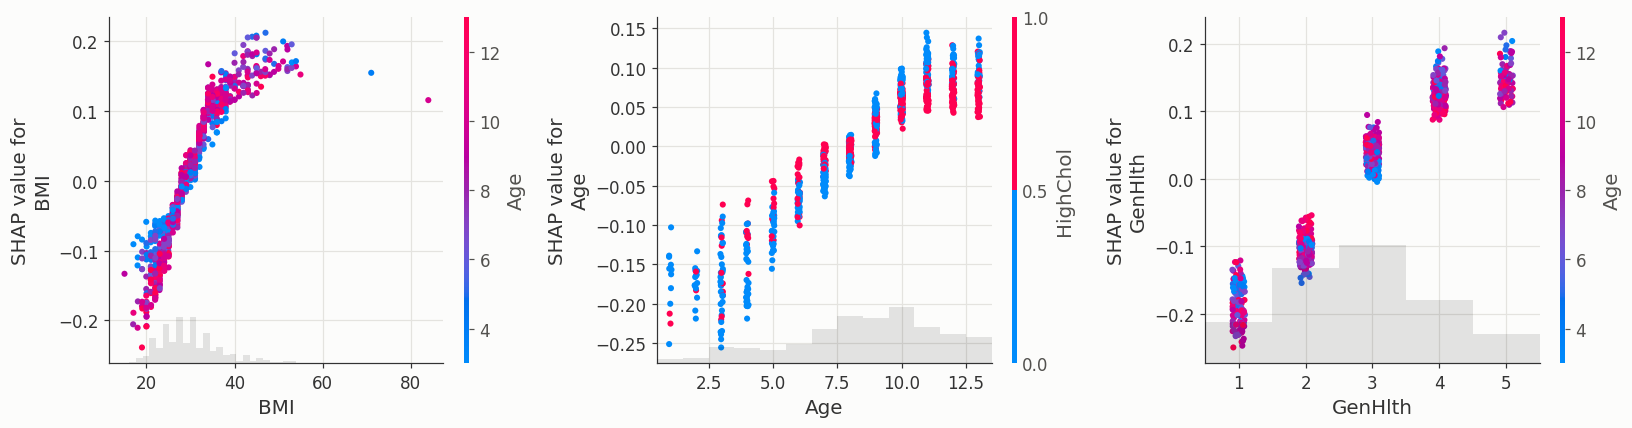

In [13]:
# Dependence plots for key features: are the learned relationships plausible?
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, f in zip(axes, ["BMI", "Age", "GenHlth"]):
    shap.plots.scatter(shap_vals[MAIN][:, f], color=shap_vals[MAIN], ax=ax, show=False)
plt.tight_layout(); plt.show()

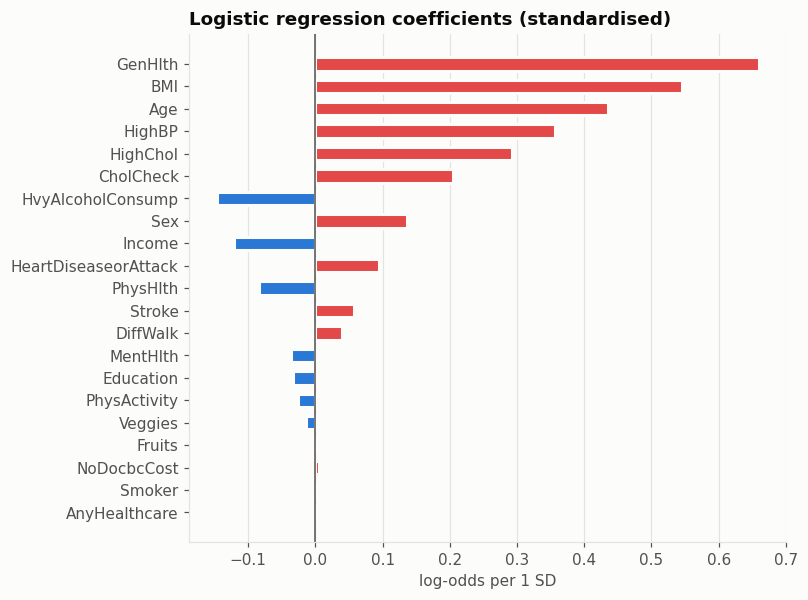

In [14]:
# Logistic regression coefficients (standardised features -> comparable magnitudes)
lr = models["Logistic regression"][-1]
coefs = pd.Series(lr.coef_[0], index=FEATURES).sort_values()
fig, ax = plt.subplots(figsize=(7, 6))
xf.plot_contributions(ax, coefs / 100, title="Logistic regression coefficients (standardised)",
                      xlabel="log-odds per 1 SD", plain_labels=False, max_features=21)
plt.show()

In [15]:
# Do the methods / models agree on what matters? (Spearman rank correlation)
global_imp = {f"PFI {n}": perm[n]["mean"] for n in models}
global_imp |= {f"SHAP {n}": xf.ShapExplainer.global_importance(shap_vals[n]) for n in models}
global_imp["|LR coef|"] = coefs.abs()
agreement = xf.rank_agreement(global_imp)
agreement.style.background_gradient(cmap="Blues", vmin=0, vmax=1).format("{:.2f}")

,PFI Logistic regression,PFI Random forest,PFI Gradient boosting,PFI Neural network,SHAP Logistic regression,SHAP Random forest,SHAP Gradient boosting,SHAP Neural network,|LR coef|
PFI Logistic regression,1.00,0.89,0.93,0.90,0.85,0.71,0.77,0.73,0.87
PFI Random forest,0.89,1.00,0.91,0.90,0.85,0.81,0.84,0.82,0.81
PFI Gradient boosting,0.93,0.91,1.00,0.95,0.82,0.73,0.82,0.70,0.87
PFI Neural network,0.90,0.90,0.95,1.00,0.86,0.76,0.86,0.72,0.89
SHAP Logistic regression,0.85,0.85,0.82,0.86,1.00,0.92,0.95,0.91,0.95
SHAP Random forest,0.71,0.81,0.73,0.76,0.92,1.00,0.94,0.89,0.81
SHAP Gradient boosting,0.77,0.84,0.82,0.86,0.95,0.94,1.00,0.92,0.91
SHAP Neural network,0.73,0.82,0.70,0.72,0.91,0.89,0.92,1.00,0.81
|LR coef|,0.87,0.81,0.87,0.89,0.95,0.81,0.91,0.81,1.00


## 6. Local explanations – one person *(what the patient would see)*

SHAP and LIME for the same person. LIME weights are local-surrogate coefficients (also probability units, but for discretised features), so compare **signs and ranking**, not magnitudes.

In [16]:
lime_expl = xf.LimeExplainer(main, X_train)

# Pick an example person: high predicted risk, true positive
risk_test = pd.Series(main.predict_proba(X_explain)[:, 1], index=X_explain.index)
pid = risk_test[(risk_test > 0.7) & (y_test.loc[X_explain.index] == 1)].index[0]
x = X_test.loc[pid]
print(f"Person {pid}: predicted risk {risk_test[pid]:.0%}, true label {y_test[pid]}")
pd.DataFrame({"value": x, "meaning": [xf.describe_value(f, v) for f, v in x.items()]})

Person 42369: predicted risk 71%, true label 1


,value,meaning
HighBP,1,Yes
HighChol,1,Yes
CholCheck,1,Yes
BMI,33,33
Smoker,0,No
Stroke,0,No
HeartDiseaseorAttack,0,No
PhysActivity,0,No
Fruits,0,No
Veggies,0,No


LIME local surrogate R^2: 0.37   |  top-5 overlap SHAP vs LIME: 0.43


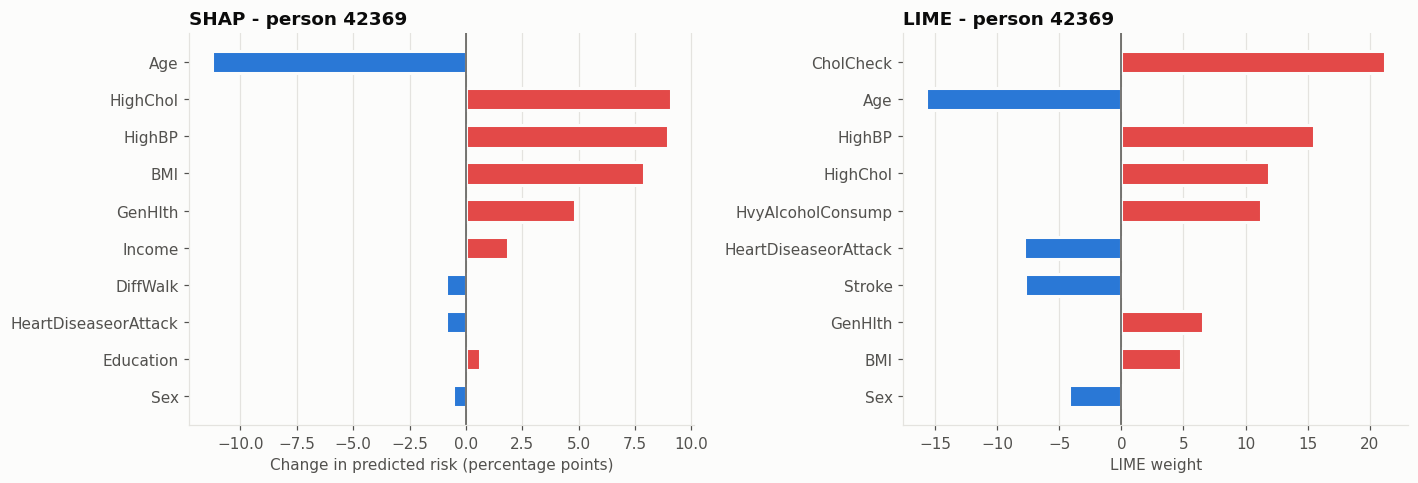

In [17]:
pos = X_explain.index.get_loc(pid)
shap_local = pd.Series(shap_vals[MAIN].values[pos], index=FEATURES)
lime_local, lime_raw = lime_expl.explain(x)
print(f"LIME local surrogate R^2: {lime_raw.score:.2f}   |  top-5 overlap SHAP vs LIME: {xf.topk_overlap(shap_local, lime_local):.2f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
xf.plot_contributions(axes[0], shap_local, title=f"SHAP - person {pid}", plain_labels=False)
xf.plot_contributions(axes[1], lime_local, title=f"LIME - person {pid}", xlabel="LIME weight", plain_labels=False)
plt.tight_layout(); plt.show()

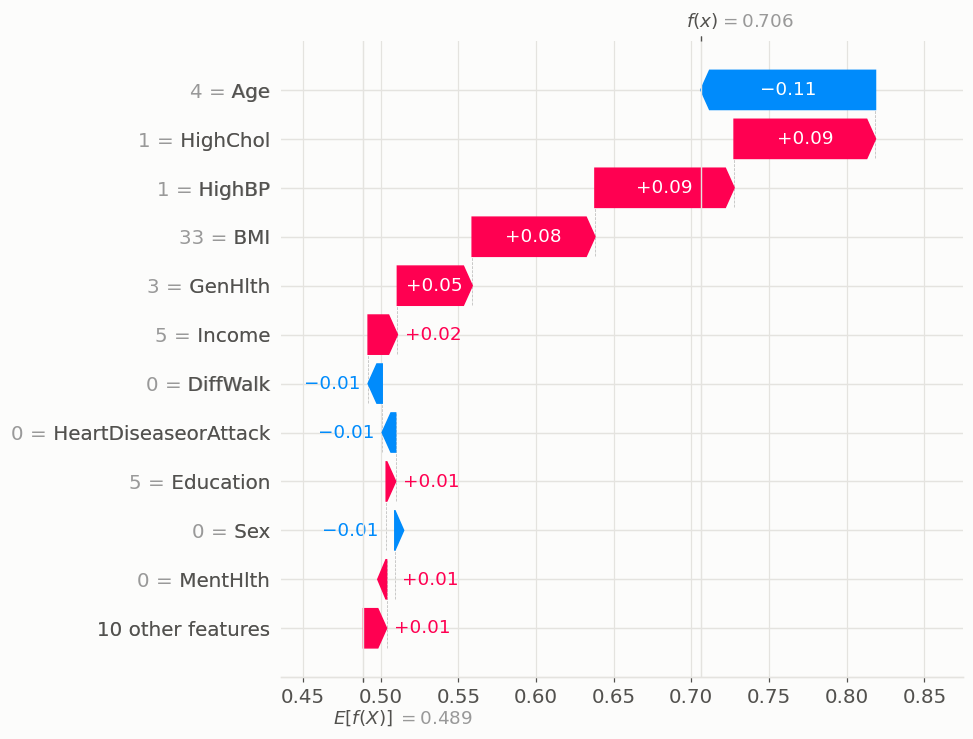

In [18]:
shap.plots.waterfall(shap_vals[MAIN][pos], max_display=12)

## 7. Validating the explanations *(Report §2–4)*

1. **Agreement** – SHAP vs LIME top-k overlap across many persons.
2. **Faithfulness (deletion test)** – removing the features an explanation calls important should change the prediction more than removing random features.
3. **Stability** – does LIME give the same answer when re-run?
4. **Advice safety** – for every actionable feature: does the *healthy* change actually lower predicted risk? If not, feedback based on this model is unsafe.

In [19]:
# 7.1 Agreement SHAP vs LIME on 50 persons (LIME is slow-ish)
sub = X_explain.iloc[:50]
overlaps, fidelities = [], []
for i, (idx, xi) in enumerate(sub.iterrows()):
    lw, lr_ = lime_expl.explain(xi, num_samples=2000)
    overlaps.append(xf.topk_overlap(pd.Series(shap_vals[MAIN].values[i], index=FEATURES), lw, k=5))
    fidelities.append(lr_.score)
print(f"Top-5 Jaccard SHAP vs LIME: mean {np.mean(overlaps):.2f}  |  LIME surrogate R^2: mean {np.mean(fidelities):.2f}")

Top-5 Jaccard SHAP vs LIME: mean 0.47  |  LIME surrogate R^2: mean 0.48


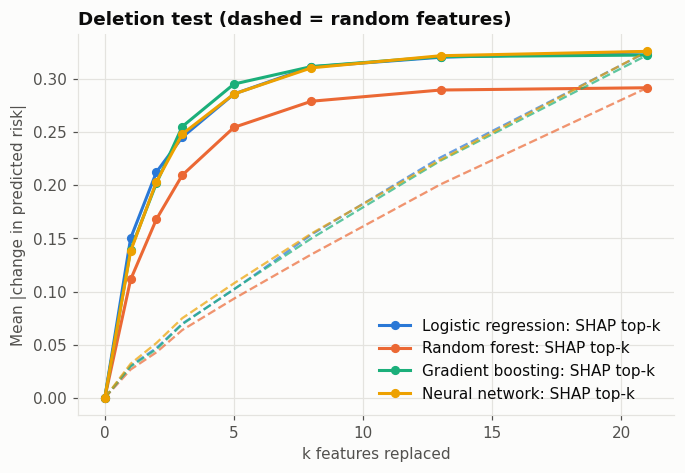

In [20]:
# 7.2 Deletion test: SHAP ranking vs random ranking (per model)
fig, ax = plt.subplots(figsize=(7, 4.5))
for name, m in models.items():
    dt = xf.deletion_test(m, X_explain.iloc[:300], shap_vals[name].values[:300], X_train)
    ax.plot(dt.index, dt["explanation"], lw=2, marker="o", ms=5, color=MODEL_COLORS[name], label=f"{name}: SHAP top-k")
    ax.plot(dt.index, dt["random"], lw=1.5, ls="--", color=MODEL_COLORS[name], alpha=0.7)
ax.set(title="Deletion test (dashed = random features)", xlabel="k features replaced",
       ylabel="Mean |change in predicted risk|")
ax.legend(); plt.show()

In [21]:
# 7.3 LIME stability for the example person
stab = xf.lime_stability(lime_expl, x, n_runs=5)
print(f"Mean top-5 Jaccard across LIME runs: {stab['mean_topk_jaccard']:.2f}")
stab["runs"].T.round(3)

Mean top-5 Jaccard across LIME runs: 1.00


,0,1,2,3,4
HighBP,0.152,0.145,0.151,0.159,0.139
HighChol,0.120,0.121,0.114,0.114,0.124
CholCheck,0.218,0.208,0.224,0.223,0.224
BMI,0.049,0.054,0.049,0.058,0.044
Smoker,-0.001,0.009,-0.001,-0.003,0.006
Stroke,-0.066,-0.059,-0.058,-0.058,-0.042
HeartDiseaseorAttack,-0.083,-0.075,-0.072,-0.073,-0.067
PhysActivity,0.009,0.004,0.010,0.004,0.011
Fruits,0.017,-0.005,-0.004,0.006,0.005
Veggies,0.001,0.003,0.009,0.001,-0.000


In [22]:
# 7.4 Advice safety: does the healthy change lower risk in every model?
safety = pd.concat({name: xf.advice_safety(m, X_explain) for name, m in models.items()})
safety.style.apply(lambda r: ["background-color: #fbd9d8" if r["flag"] == "UNSAFE" else "" for _ in r], axis=1)

## 8. Error analysis and bias audit *(Report §4)*

`TODO:` discuss whether Sex, Age, Income, Education are ethical to use (they are not actionable, and Income/Education are proxies of socio-economic status). Consider training a model without them and comparing performance + explanations.

In [23]:
for f in SENSITIVE:
    print(f"\n=== {xf.label(f)} ===")
    display(xf.subgroup_report(main, X_test, y_test, f))


=== Sex ===


,n,prevalence,mean predicted risk,AUC,Recall,Specificity,FNR (missed cases)
group,,,,,,,
Female,7675,0.482,0.484,0.841,0.792,0.728,0.208
Male,6464,0.521,0.522,0.815,0.800,0.674,0.200



=== Age group ===


,n,prevalence,mean predicted risk,AUC,Recall,Specificity,FNR (missed cases)
group,,,,,,,
18-24,181,0.033,0.105,0.884,0.167,0.983,0.833
25-29,282,0.096,0.118,0.829,0.185,0.984,0.815
30-34,448,0.150,0.176,0.836,0.433,0.955,0.567
35-39,575,0.263,0.250,0.850,0.464,0.913,0.536
40-44,671,0.319,0.320,0.836,0.603,0.851,0.397
45-49,913,0.347,0.374,0.837,0.650,0.820,0.350
50-54,1361,0.439,0.446,0.826,0.719,0.776,0.281
55-59,1720,0.508,0.503,0.826,0.777,0.729,0.223
60-64,2032,0.563,0.554,0.819,0.832,0.640,0.168



=== Education level ===


,n,prevalence,mean predicted risk,AUC,Recall,Specificity,FNR (missed cases)
group,,,,,,,
Elementary,321,0.735,0.701,0.771,0.932,0.424,0.068
Some high school,663,0.674,0.663,0.745,0.906,0.444,0.094
High school grad,3869,0.575,0.571,0.795,0.827,0.598,0.173
Some college,3966,0.517,0.525,0.822,0.816,0.669,0.184
College grad,5307,0.396,0.400,0.847,0.704,0.805,0.296



=== Income level ===


,n,prevalence,mean predicted risk,AUC,Recall,Specificity,FNR (missed cases)
group,,,,,,,
<$10k,727,0.629,0.656,0.790,0.902,0.496,0.098
$10-15k,913,0.710,0.688,0.758,0.920,0.419,0.080
$15-20k,1117,0.659,0.630,0.774,0.860,0.520,0.140
$20-25k,1339,0.616,0.614,0.785,0.869,0.521,0.131
$25-35k,1599,0.562,0.562,0.791,0.824,0.598,0.176
$35-50k,2097,0.515,0.505,0.810,0.783,0.683,0.217
$50-75k,2208,0.457,0.462,0.822,0.755,0.731,0.245
>$75k,4139,0.343,0.357,0.849,0.651,0.837,0.349


In [24]:
fn, fp = xf.error_cases(main, X_test, y_test, k=10)
print("Most confident FALSE NEGATIVES (diabetes, predicted low risk):")
display(fn)
print("Most confident FALSE POSITIVES (no diabetes, predicted high risk):")
display(fp)

Most confident FALSE NEGATIVES (diabetes, predicted low risk):


,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,risk,y
66055,0,0,1,20,0,0,0,1,1,1,...,1,0,0,0,1,2,6,7,0.017,1
38149,0,0,1,23,0,0,0,1,0,1,...,1,0,0,0,1,5,6,8,0.027,1
56227,0,0,1,26,1,0,0,1,1,1,...,1,0,0,0,0,9,6,8,0.031,1
49746,0,0,1,22,0,0,0,1,1,1,...,1,1,0,0,1,6,6,8,0.033,1
55644,0,1,1,22,0,0,0,1,0,1,...,1,0,0,0,0,8,6,7,0.034,1
51216,0,0,1,24,1,0,0,1,0,1,...,2,5,1,0,0,3,6,5,0.038,1
60873,0,0,1,24,0,0,0,1,1,1,...,1,0,1,0,0,9,6,4,0.040,1
37605,0,0,1,28,0,0,0,1,1,1,...,2,15,0,0,0,3,6,8,0.043,1
39887,0,0,1,28,0,0,0,1,0,0,...,1,0,0,0,1,8,4,7,0.045,1
50392,0,0,1,24,0,0,0,1,1,1,...,2,0,0,0,0,2,6,7,0.045,1


Most confident FALSE POSITIVES (no diabetes, predicted high risk):


,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,risk,y
8841,1,1,1,38,0,1,1,1,1,1,...,5,30,30,1,1,8,6,7,0.936,0
781,1,1,1,46,1,0,1,0,1,1,...,5,4,10,1,1,9,4,3,0.936,0
7005,1,1,1,43,0,0,1,1,0,1,...,5,0,30,1,1,6,6,1,0.932,0
19581,1,1,1,42,0,0,1,0,1,1,...,5,0,7,1,0,12,2,3,0.931,0
3365,1,1,1,48,1,0,0,1,1,1,...,4,3,5,1,0,9,3,1,0.930,0
20936,1,1,1,46,1,0,1,1,1,0,...,5,15,15,1,1,7,4,3,0.928,0
17343,1,1,1,46,1,0,0,0,1,1,...,5,0,30,1,1,10,6,7,0.920,0
6426,1,1,1,45,1,0,0,0,0,1,...,5,8,30,1,0,7,2,3,0.919,0
14502,1,1,1,43,0,0,1,0,1,1,...,5,0,30,1,0,12,5,2,0.919,0
20389,1,1,1,44,1,0,1,0,0,0,...,5,14,30,0,1,7,4,4,0.918,0


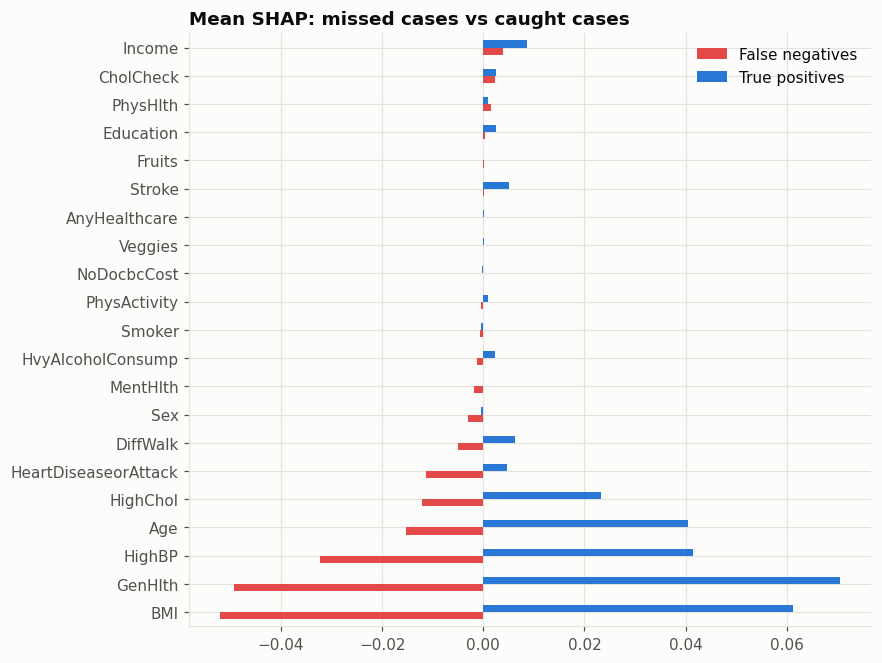

In [25]:
# What drives the errors? Mean SHAP among false negatives vs true positives in the explained sample
p_ex = main.predict_proba(X_explain)[:, 1]
y_ex = y_test.loc[X_explain.index].to_numpy()
S = pd.DataFrame(shap_vals[MAIN].values, columns=FEATURES)
comp = pd.DataFrame({
    "False negatives": S[(y_ex == 1) & (p_ex < 0.5)].mean(),
    "True positives": S[(y_ex == 1) & (p_ex >= 0.5)].mean(),
})
comp.sort_values("False negatives").plot.barh(figsize=(8, 7), color=[COLORS["increase"], COLORS["decrease"]],
                                              title="Mean SHAP: missed cases vs caught cases")
plt.show()

## 9. Actionability – what can the patient change?

In [26]:
print("Actionable:", ACTIONABLE, "\nMedical (changeable with treatment):", MEDICAL)
cf = xf.counterfactual_search(main, x, max_changes=3)
cf

Actionable: ['BMI', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump'] 
Medical (changeable with treatment): ['HighBP', 'HighChol', 'GenHlth', 'MentHlth', 'PhysHlth']


,step,risk
0,current,0.706
1,Body mass index (BMI): 33 -> 28,0.563
2,Body mass index (BMI): 28 -> 23,0.511
3,Physically active: No -> Yes,0.494


In [27]:
xf.what_if(main, x, BMI=max(x.BMI - 5, 22), PhysActivity=1)

{'before': 0.7060853147383676,
 'after': 0.5622180585730789,
 'x_new': HighBP                   1
 HighChol                 1
 CholCheck                1
 BMI                     28
 Smoker                   0
 Stroke                   0
 HeartDiseaseorAttack     0
 PhysActivity             1
 Fruits                   0
 Veggies                  0
 HvyAlcoholConsump        0
 AnyHealthcare            1
 NoDocbcCost              0
 GenHlth                  3
 MentHlth                 0
 PhysHlth                 3
 DiffWalk                 0
 Sex                      0
 Age                      4
 Education                5
 Income                   5
 Name: 42369, dtype: int64}

## 10. Stakeholder figures *(Report §3–4)*

Each audience gets its own figure set; all saved to `figures/<stakeholder>/`. These are **first drafts** – iterate on them.

### 10.1 Head of data science – debugging and validation
Needs: high fidelity, global importance, error analysis, edge cases. → technical names, uncertainty, all models side-by-side.

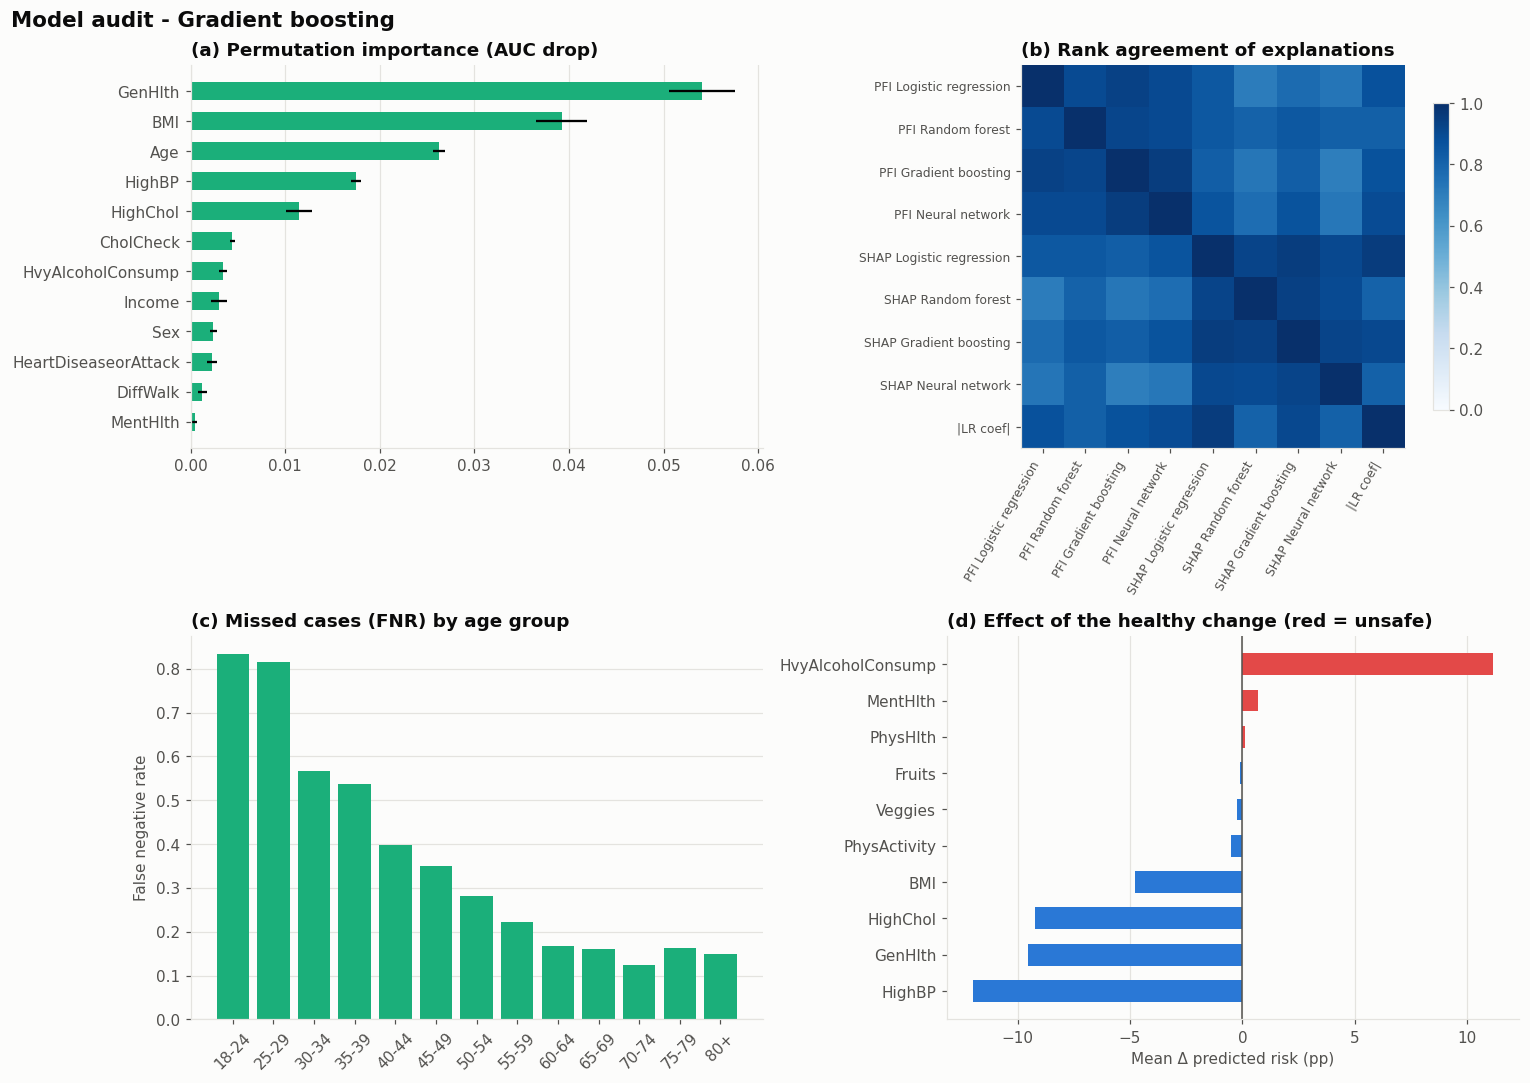

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
# (a) permutation importance of main model with error bars
pi = perm[MAIN].sort_values("mean").tail(12)
axes[0, 0].barh(pi.index, pi["mean"], xerr=pi["std"], color=MODEL_COLORS[MAIN], height=0.6)
axes[0, 0].set(title="(a) Permutation importance (AUC drop)"); axes[0, 0].grid(axis="y", visible=False)
# (b) method agreement
im = axes[0, 1].imshow(agreement.to_numpy(dtype=float), cmap="Blues", vmin=0, vmax=1)
axes[0, 1].set_xticks(range(len(agreement)), agreement.columns, rotation=60, ha="right", fontsize=8)
axes[0, 1].set_yticks(range(len(agreement)), agreement.index, fontsize=8)
axes[0, 1].set_title("(b) Rank agreement of explanations"); axes[0, 1].grid(False)
fig.colorbar(im, ax=axes[0, 1], shrink=0.8)
# (c) subgroup error: FNR by age
sg = xf.subgroup_report(main, X_test, y_test, "Age")
axes[1, 0].bar(sg.index, sg["FNR (missed cases)"], color=MODEL_COLORS[MAIN])
axes[1, 0].set(title="(c) Missed cases (FNR) by age group", ylabel="False negative rate")
axes[1, 0].tick_params(axis="x", rotation=45); axes[1, 0].grid(axis="x", visible=False)
# (d) advice safety
s = safety.loc[MAIN]["mean Δ risk (pp)"].sort_values()
axes[1, 1].barh(s.index, s.values, color=[COLORS["increase"] if v > 0 else COLORS["decrease"] for v in s], height=0.6)
axes[1, 1].axvline(0, color=COLORS["text2"], lw=1)
axes[1, 1].set(title="(d) Effect of the healthy change (red = unsafe)", xlabel="Mean Δ predicted risk (pp)")
axes[1, 1].grid(axis="y", visible=False)
fig.suptitle(f"Model audit - {MAIN}", fontsize=14, fontweight="bold", x=0.01, ha="left")
plt.tight_layout()
xf.savefig(fig, "data_scientist", "audit_overview")
plt.show()

### 10.2 Director of patient organisation – "Can we trust this?"
Needs: high-level logic, proof of reliability, no jargon. → plain labels, natural frequencies ("out of 100 people"), few elements.

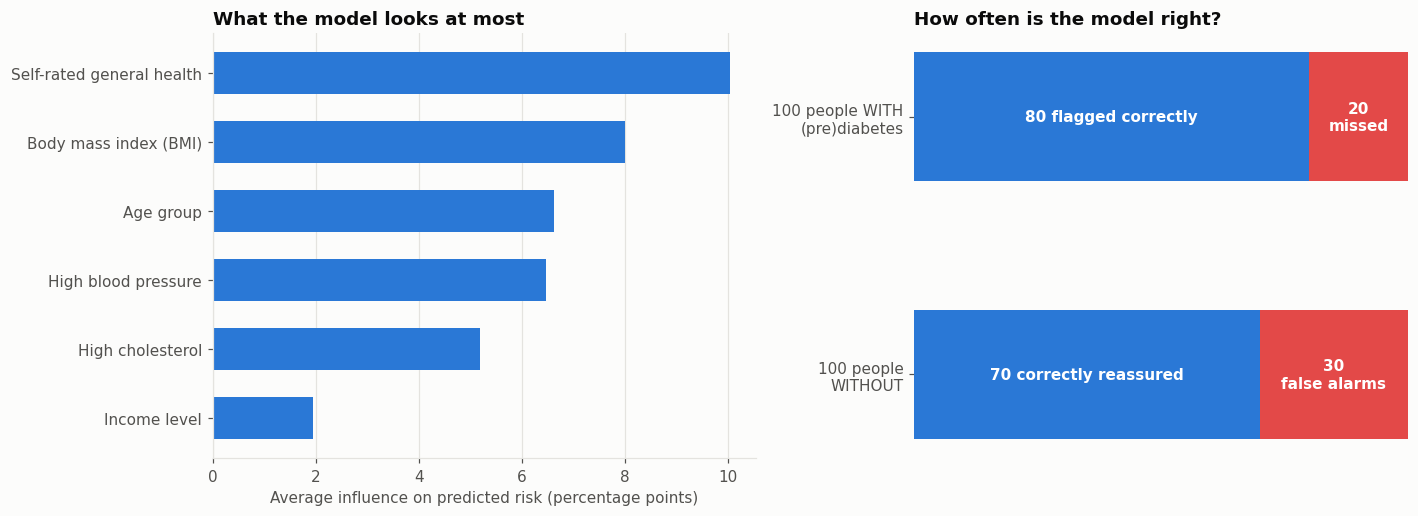

In [29]:
m = xf.evaluate(main, X_test, y_test)
glob = xf.ShapExplainer.global_importance(shap_vals[MAIN]).head(6)[::-1]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), gridspec_kw={"width_ratios": [1.1, 1]})
ax = axes[0]
ax.barh([xf.label(f) for f in glob.index], glob.values * 100, color=COLORS["decrease"], height=0.6)
ax.set(title="What the model looks at most", xlabel="Average influence on predicted risk (percentage points)")
ax.grid(axis="y", visible=False)

ax = axes[1]
caught, missed = round(100 * m["Recall (sensitivity)"]), 100 - round(100 * m["Recall (sensitivity)"])
cleared, false_alarm = round(100 * m["Specificity"]), 100 - round(100 * m["Specificity"])
rows = ["100 people\nWITHOUT", "100 people WITH\n(pre)diabetes"]   # barh draws bottom-up
ax.barh(rows, [cleared, caught], color=COLORS["decrease"], height=0.5)
ax.barh(rows, [false_alarm, missed], left=[cleared, caught], color=COLORS["increase"], height=0.5)
ax.text(caught / 2, 1, f"{caught} flagged correctly", ha="center", va="center", color="white", fontweight="bold")
ax.text(caught + missed / 2, 1, f"{missed}\nmissed", ha="center", va="center", color="white", fontweight="bold")
ax.text(cleared / 2, 0, f"{cleared} correctly reassured", ha="center", va="center", color="white", fontweight="bold")
ax.text(cleared + false_alarm / 2, 0, f"{false_alarm}\nfalse alarms", ha="center", va="center", color="white", fontweight="bold")
ax.set(xlim=(0, 100), title="How often is the model right?", xticks=[]); ax.grid(False)
ax.spines[["left", "bottom"]].set_visible(False)
plt.tight_layout()
xf.savefig(fig, "director", "trust_overview")
plt.show()

### 10.3 Patient – "Why is my risk high, and what can I change?"
Needs: personal, actionable, understandable. → split into *things you can change* vs *things you cannot*, show the effect of realistic changes. Never show unsafe features as advice (see §7.4).

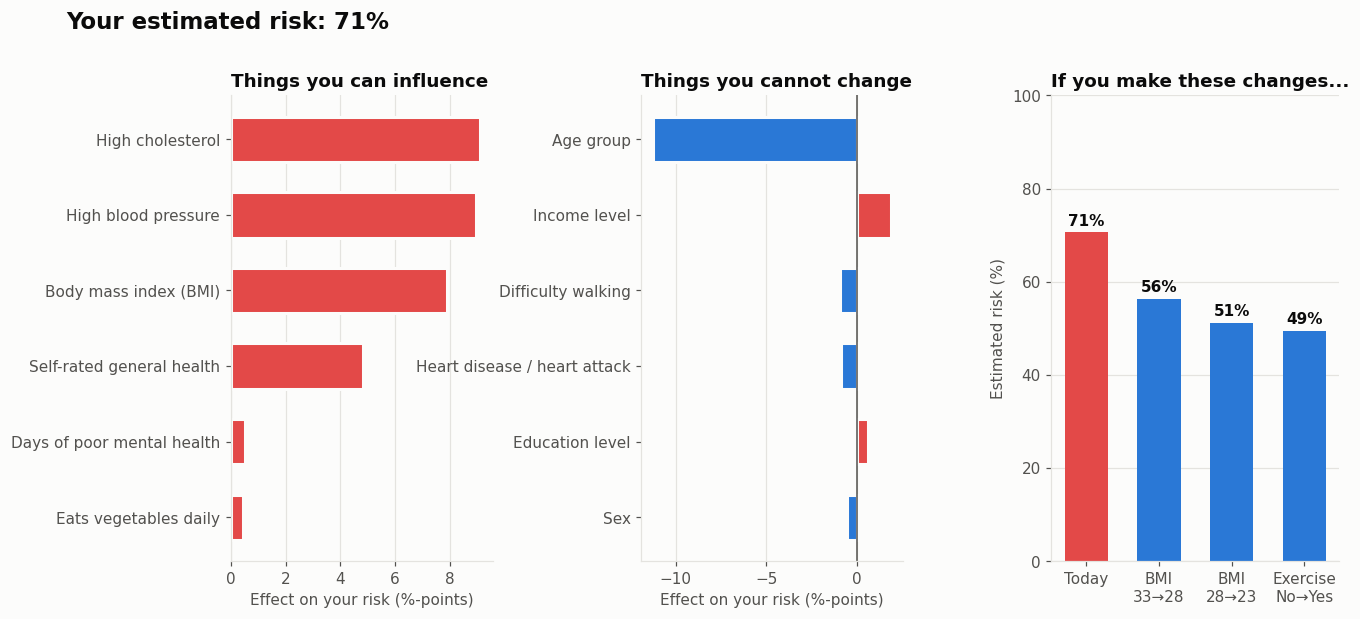

In [30]:
contrib = shap_local.copy()
changeable = contrib[[f for f in FEATURES if CODEBOOK[f].actionable in ("yes", "medical")]]
fixed = contrib[[f for f in FEATURES if CODEBOOK[f].actionable == "no"]]

fig = plt.figure(figsize=(13, 5.5))
gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 1.1], wspace=0.55)
xf.plot_contributions(fig.add_subplot(gs[0]), changeable, title="Things you can influence", xlabel="Effect on your risk (%-points)", max_features=6)
xf.plot_contributions(fig.add_subplot(gs[1]), fixed, title="Things you cannot change", xlabel="Effect on your risk (%-points)", max_features=6)

ax = fig.add_subplot(gs[2])
steps = cf.copy(); steps["risk"] *= 100
ax.bar(range(len(steps)), steps["risk"], color=[COLORS["increase"]] + [COLORS["decrease"]] * (len(steps) - 1), width=0.6)
for i, r in enumerate(steps["risk"]):
    ax.text(i, r + 1.5, f"{r:.0f}%", ha="center", fontweight="bold")
ax.set_xticks(range(len(steps)), ["Today"] + [s.replace("Body mass index (BMI)", "BMI").replace("Physically active", "Exercise").replace(" -> ", "→").replace(": ", "\n") for s in steps["step"][1:]])
ax.set(ylim=(0, 100), title="If you make these changes...", ylabel="Estimated risk (%)"); ax.grid(axis="x", visible=False)
fig.suptitle(f"Your estimated risk: {risk_test[pid]:.0%}", fontsize=15, fontweight="bold", x=0.01, ha="left", y=1.02)
xf.savefig(fig, "patient", f"patient_{pid}")
plt.show()

## TODO list
- [ ] Hyper-parameter tuning (validation set) and final model choice
- [ ] Decide what to do with unsafe features found in §7.4 (e.g. remove from advice, monotonic constraints in HistGB, retrain without them) – **bonus**
- [ ] Model without sensitive features – compare performance and explanations
- [ ] Iterate stakeholder figures (cognitive load for director, disclaimer + plain language for patient)
- [ ] Prepare 10-min presentation for each stakeholder